# Example chromatin and expression deconvolution

In this notebook, we show a small locus is deconvolved for both the chromatin and for transcripts within the window.

In [1]:
# Preamble, notebook setup and imports

%load_ext autoreload
%autoreload 2
%matplotlib inline
%config InlineBackend.figure_format = 'retina'

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


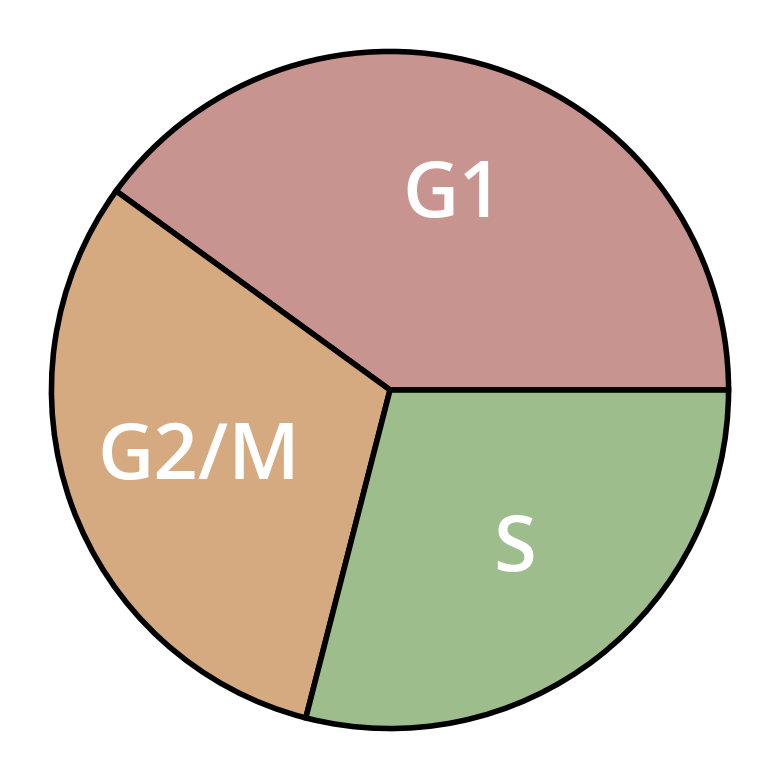

In [129]:
import matplotlib.pyplot as plt
from src.plot_helpers import color_for_key

# Define the phases and their proportions
phases = ['RG1', 'G2M', 'S']
sizes = [40, 31, 29]

# Define colors matching the reference image
colors = [color_for_key(phase) for phase in phases]

# Create the pie chart
fig, ax = plt.subplots(figsize=(4, 4))

# Custom function to return phase labels instead of percentages
def make_autopct(phases):
    def my_autopct(pct):
        total = sum(sizes)
        val = int(round(pct*total/100.0))
        phase = dict(zip(sizes, phases))[val]
        phase = phase.replace('RG1', 'G1').replace("G2M", 'G2/M')
        return phase

    return my_autopct

wedges, texts, autotexts = ax.pie(sizes, 
                                    colors=colors,
                                    autopct=make_autopct(phases),
                                    startangle=0,
                                    textprops={'fontsize': 32, 'weight': 
                                               'semibold', 'color': 'white'},
                                    wedgeprops={'edgecolor': 'black', 'linewidth': 2})

# Make the percentage text white and bold
for autotext in autotexts:
    autotext.set_color('white')
    autotext.set_fontsize(28)

# Equal aspect ratio ensures that pie is drawn as a circle
ax.axis('equal')

plt.tight_layout()


Text(0.5, 0, 'Count')

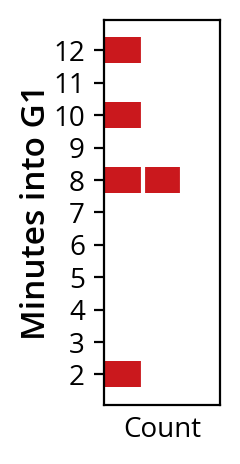

In [230]:
data = [1, 0, 0, 0, 0, 0, 2, 0, 1, 0, 1]
ys = np.arange(2, 13)
plt.figure(figsize=(0.75, 2.5))
plt.barh(ys, data, color=plt.cm.Reds(0.75))
plt.xlim(0, 3)
plt.axvline(1, color='white')
plt.axvline(2, color='white')
plt.xticks([])
plt.yticks(ys)
plt.ylabel("Minutes into G1", fontweight='demi', fontsize=12, labelpad=0, va='bottom')
plt.xlabel("Count")

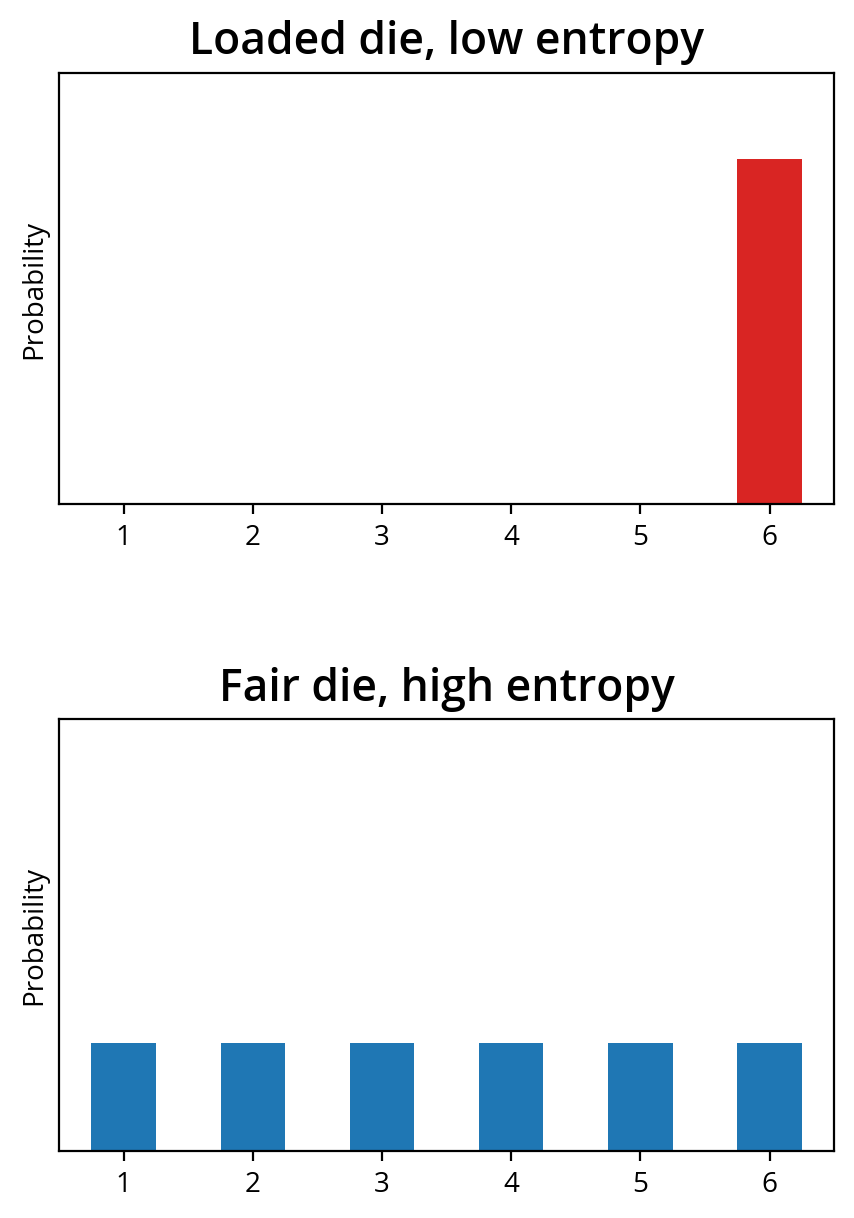

In [171]:
plt.figure(figsize=(5, 7))
plt.subplot(2, 1, 1)
plt.hist([6], bins=np.arange(0.5, 7)+0.25,
        width=0.5, color=plt.cm.Reds(0.7))
plt.xlim(0.5, 6.5)
plt.title("Loaded die, low entropy", fontweight='demi', fontsize=16, pad=7)
plt.yticks([])
plt.ylabel("Probability")
plt.ylim(0, 1.25)

plt.subplot(2, 1, 2)
plt.hist([1, 2, 3, 4, 5, 6], bins=np.arange(0.5, 7)+0.25,
        width=0.5)
plt.xlim(0.5, 6.5)
plt.ylim(0, 4)
plt.ylabel("Probability")
plt.title("Fair die, high entropy", fontweight='demi', fontsize=16, pad=7)
plt.yticks([])
plt.subplots_adjust(hspace=0.5)

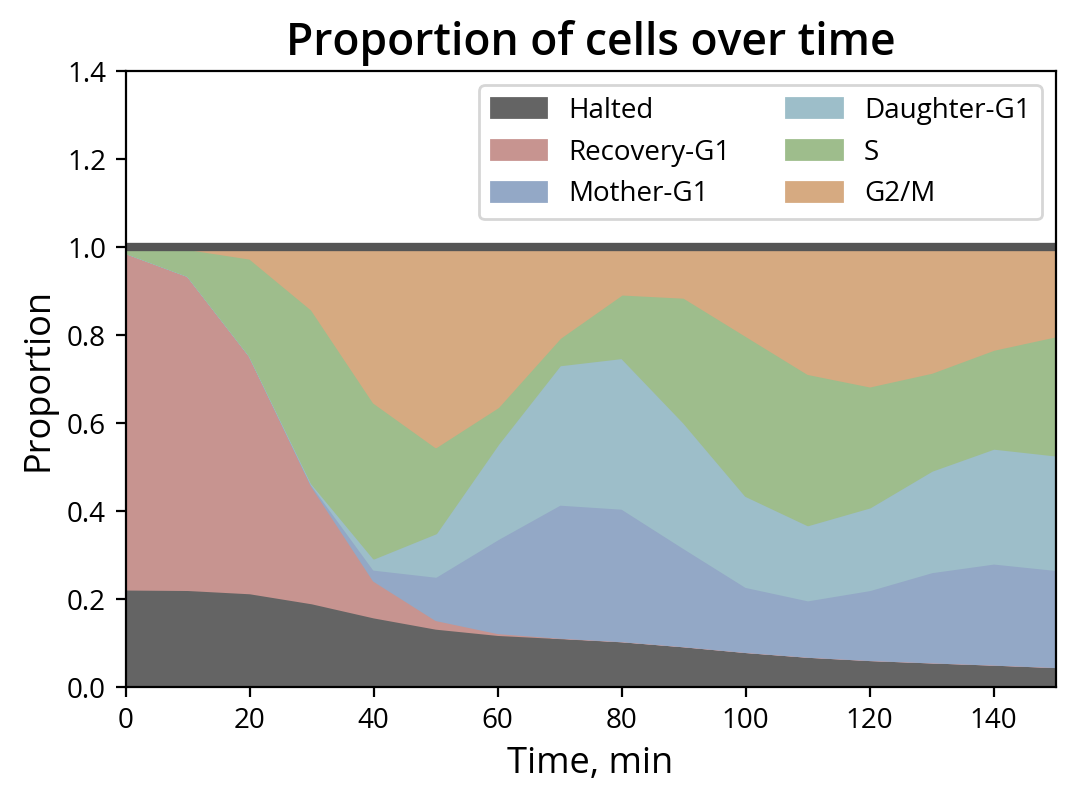

In [49]:
from src.config import load_default_chrom_configs


config, _ = load_default_chrom_configs()

config.plot_mass(normalize=True)


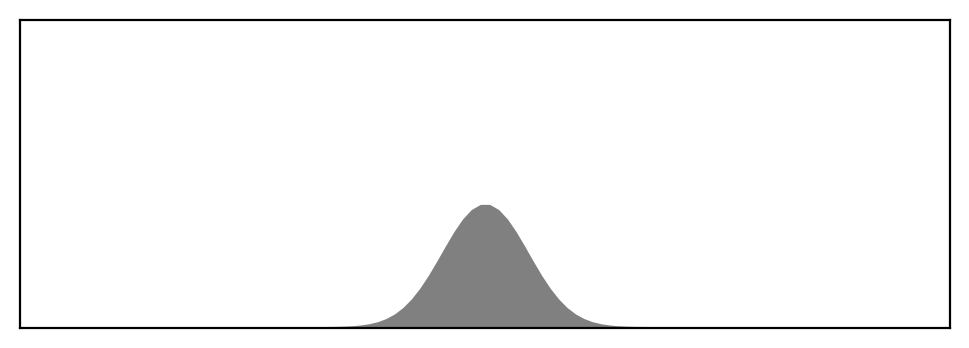

In [56]:
from scipy.stats.distributions import norm
from src.figure_configs import save_figure_for_paper
xs = np.linspace(-10, 10, 100)
ys = norm.pdf(xs, loc=0, scale=1)

plt.figure(figsize=(6, 2))
plt.fill_between(xs, 0, ys, color='gray')
plt.xticks([])
plt.yticks([])
plt.ylim(0, 1)

plt.savefig('example_norm.png', dpi=300, transparent=True, bbox_inches='tight')

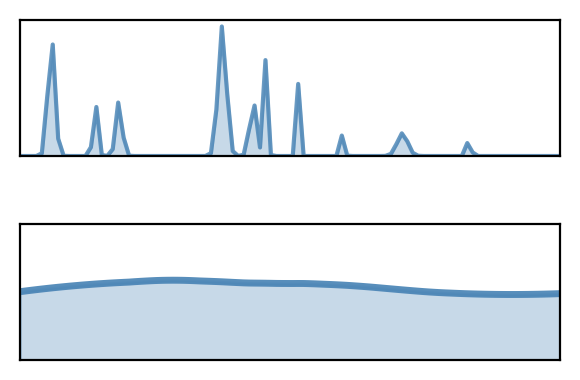

In [86]:
import matplotlib.pyplot as plt
import numpy as np
from scipy import signal

# Set random seed for reproducibility
np.random.seed(42)

# Create x-axis
x = np.linspace(0, 10, 100)

# Row 1: High-frequency data with multiple normal curves
# Create base signal with multiple Gaussian peaks
high_freq_signal = np.zeros_like(x)

# Add 15 random Gaussian curves
num_curves = 10
for i in range(num_curves):
    center = np.random.uniform(0, 10)
    amplitude = np.random.uniform(0.3, 2)
    width = np.random.uniform(0.01, 0.1)
    high_freq_signal += amplitude * np.exp(-((x - center) ** 2) / (2 * width ** 2))

# Normalize to 0-1 range
high_freq_signal = high_freq_signal / np.max(high_freq_signal)

# Row 2: Smoothed low-frequency curve (regularized version)
# Apply heavy smoothing using Savitzky-Golay filter
window_length = 41  # Must be odd
polyorder = 2

# Apply sliding window smoothing before regularization
window_size = 50
high_freq_signal_smoothed = np.convolve(high_freq_signal, np.ones(window_size)/\
    window_size, mode='same')

low_freq_signal = signal.savgol_filter(high_freq_signal_smoothed, window_length, polyorder)

# Create the plot
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(3, 2))

# Plot 1: High-frequency data
ax1.plot(x, high_freq_signal, linewidth=1.5, color='steelblue', alpha=0.8)
ax1.fill_between(x, high_freq_signal, alpha=0.3, color='steelblue')
ax1.set_ylim(0.0, 1.05)
ax1.set_xlim(0, 10)

# Plot 2: Low-frequency smoothed data
ax2.plot(x, low_freq_signal+0.5, linewidth=2.5, color='steelblue', alpha=0.9)
ax2.fill_between(x, low_freq_signal+0.5, alpha=0.3, color='steelblue')

ax2.set_ylim(0.0, 1.05)
ax2.set_xlim(0, 10)
ax2.set_xticks([])
ax2.set_yticks([])

ax1.set_xticks([])
ax1.set_yticks([])

plt.tight_layout()
plt.subplots_adjust(hspace=0.5)

(0.0, 6.283185307179586)

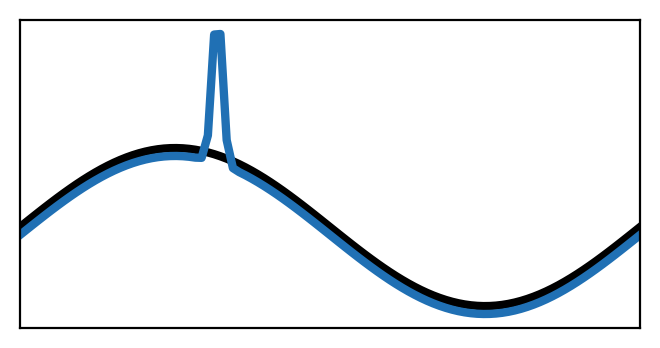

In [119]:

x = np.linspace(0, 2*np.pi, 100)
y = np.sin(x)

differences = np.zeros_like(y) + norm.pdf(x, loc=2, scale=0.05)*0.25
y_2 = np.sin(x) + differences

plt.figure(figsize=(4, 2))

plt.plot(x, y+0.1, color=plt.cm.Greys(1.), lw=3)
plt.plot(x, y_2, color=plt.cm.Blues(0.75), lw=3)
plt.xticks([])
plt.yticks([])
plt.xlim(0, np.pi*2)

(0.0, 3.9269908169872414)

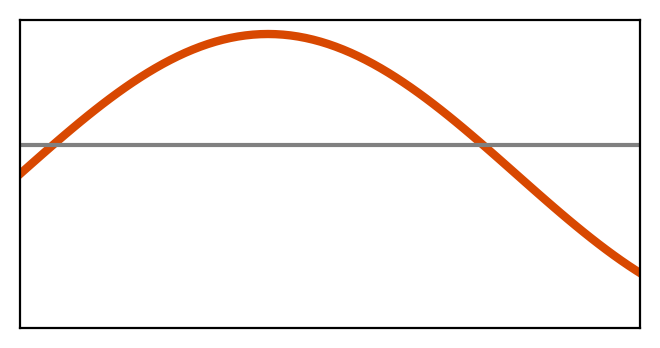

In [121]:

x = np.linspace(0, 1.5*np.pi, 100)
y = np.sin(x)

plt.figure(figsize=(4, 2))

plt.plot(x, y, color=plt.cm.Oranges(0.75), lw=3)
plt.axhline(y.mean(), c='gray')
plt.xticks([])
plt.yticks([])
plt.xlim(0, np.pi*1.25)

In [126]:
from PIL import Image

def crop_animated_gif(input_path: str, output_path: str, crop_box: tuple) -> None:
    """
    Load and crop an animated GIF, preserving all frames and timing.

    Args:
        input_path:  Path to the source GIF file
        output_path: Path to save the cropped GIF
        crop_box:    Crop region as (left, top, right, bottom) in pixels
    """
    gif = Image.open(input_path)

    frames = []
    durations = []

    try:
        while True:
            # Composite the current frame onto a full RGBA canvas.
            # This resolves disposal methods and partial-frame deltas
            # that GIFs use to reduce file size.
            canvas = Image.new("RGBA", gif.size, (0, 0, 0, 0))
            canvas.paste(gif.convert("RGBA"), (0, 0))

            cropped = canvas.crop(crop_box)

            # Convert to "P" (palette) mode to keep file sizes small,
            # falling back to RGBA if palette conversion has issues.
            try:
                frame = cropped.convert("P", palette=Image.ADAPTIVE, dither=Image.Dither.NONE)
            except Exception:
                frame = cropped

            frames.append(frame)

            # Capture per-frame duration (default to 100ms if missing)
            duration = gif.info.get("duration", 100)
            durations.append(duration)

            gif.seek(gif.tell() + 1)  # advance to the next frame

    except EOFError:
        pass  # no more frames

    if not frames:
        raise ValueError("No frames found in GIF.")

    # Save all frames as an animated GIF
    frames[0].save(
        output_path,
        save_all=True,
        append_images=frames[1:],
        loop=gif.info.get("loop", 0),        # 0 = loop forever
        duration=durations,
        optimize=False,
    )
    print(f"Saved {len(frames)}-frame cropped GIF to '{output_path}'")


# crop_box = (left, top, right, bottom)
crop_animated_gif(
    input_path="/Users/trung/Downloads/Result of 12424 Position 2.gif",
    output_path="/Users/trung/Downloads/cropped_yeast.gif",
    crop_box=(270, 420, 390, 550),
)


Saved 71-frame cropped GIF to '/Users/trung/Downloads/cropped_yeast.gif'


In [128]:
import numpy as np
from PIL import Image
import cv2

def denoise_animated_gif(
    input_path: str,
    output_path: str,
    method: str = "nlmeans",       # "nlmeans" | "gaussian" | "median" | "bilateral"
    h: float = 10.0,               # nlmeans: filter strength (higher = more smoothing)
    gaussian_sigma: float = 1.0,   # gaussian: blur radius
    median_ksize: int = 3,         # median: kernel size (must be odd)
    bilateral_d: int = 9,          # bilateral: pixel neighborhood diameter
    bilateral_sigma: float = 75.0, # bilateral: color + space sigma
) -> None:
    """
    Denoise every frame of an animated GIF.

    Methods:
        nlmeans   - Best quality; removes grain while preserving edges (slowest)
        gaussian  - Fast, gentle blur; good for light noise
        median    - Great for salt-and-pepper noise
        bilateral - Blurs noise but preserves hard edges well
    """
    gif = Image.open(input_path)

    frames = []
    durations = []

    try:
        while True:
            # Reconstruct the full composited frame (handles delta frames)
            canvas = Image.new("RGBA", gif.size, (0, 0, 0, 0))
            canvas.paste(gif.convert("RGBA"), (0, 0))

            # Convert to BGR numpy array for OpenCV
            frame_np = cv2.cvtColor(np.array(canvas), cv2.COLOR_RGBA2BGR)

            # --- Apply selected denoising method ---
            if method == "nlmeans":
                denoised = cv2.fastNlMeansDenoisingColored(
                    frame_np,
                    None,
                    h=h,
                    hColor=h,
                    templateWindowSize=7,
                    searchWindowSize=21,
                )
            elif method == "gaussian":
                # Kernel size derived from sigma; must be odd
                ksize = int(gaussian_sigma * 6) | 1
                denoised = cv2.GaussianBlur(frame_np, (ksize, ksize), gaussian_sigma)

            elif method == "median":
                if median_ksize % 2 == 0:
                    raise ValueError("median_ksize must be an odd number.")
                denoised = cv2.medianBlur(frame_np, median_ksize)

            elif method == "bilateral":
                denoised = cv2.bilateralFilter(
                    frame_np, bilateral_d, bilateral_sigma, bilateral_sigma
                )
            else:
                raise ValueError(f"Unknown method '{method}'. Choose from: nlmeans, gaussian, median, bilateral.")

            # Convert back to PIL RGBA, then to palette mode for GIF
            denoised_rgba = cv2.cvtColor(denoised, cv2.COLOR_BGR2RGBA)
            result = Image.fromarray(denoised_rgba).convert(
                "P", palette=Image.ADAPTIVE, dither=Image.Dither.NONE
            )

            frames.append(result)
            durations.append(gif.info.get("duration", 100))

            gif.seek(gif.tell() + 1)

    except EOFError:
        pass

    if not frames:
        raise ValueError("No frames found in GIF.")

    frames[0].save(
        output_path,
        save_all=True,
        append_images=frames[1:],
        loop=gif.info.get("loop", 0),
        duration=durations,
        optimize=False,
    )
    print(f"Saved {len(frames)}-frame denoised GIF → '{output_path}'")


denoise_animated_gif(
    input_path="/Users/trung/Downloads/cropped_yeast.gif",
    output_path="/Users/trung/Downloads/cropped_yeast_denoised.gif",
    method="nlmeans",
    h=2.0,
)

Saved 71-frame denoised GIF → '/Users/trung/Downloads/cropped_yeast_denoised.gif'


In [2]:
from src.config import load_default_chrom_configs
from src.combined_chromatin_model import CombinedChromatinModel

# Load the chromatin configuration objects containing
# information on the CLOCCS parameters, the timing, and the predetermined alpha
# parameter values
config1, config2 = load_default_chrom_configs()
print("Replicate 1's config parameters:")
for k, v in config1.params_dic.items():
    print('\t', k, v)
print("\nReplicate 1's experimental times:\n\t", config1.timepoints)

print("\n\nReplicate 2's config parameters:")
for k, v in config2.params_dic.items():
    print('\t', k, v)
print("\nReplicate 2's experimental times:\n\t", config2.timepoints)


Replicate 1's config parameters:
	 mu0 -26.7901
	 delta 8.1805
	 sigma0 10.9885
	 sigmav 0.1424
	 lambda 68.1914
	 gamma1 0.0041
	 gamma2 0.2547
	 halted 0.2245
	 alpha 34
	 num_g1_indices 62

Replicate 1's experimental times:
	 [0, 10, 20, 30, 40, 50, 60, 70, 80, 90, 100, 110, 120, 130, 140, 150]


Replicate 2's config parameters:
	 mu0 -26.7901
	 delta 8.1805
	 sigma0 10.9885
	 sigmav 0.1424
	 lambda 68.1914
	 gamma1 0.0041
	 gamma2 0.2547
	 halted 0.2245
	 alpha 34
	 num_g1_indices 62

Replicate 2's experimental times:
	 [0, 10, 20, 30, 40, 50, 60, 70, 80, 90, 100, 110, 120, 130, 140, 150]


In [3]:
# The loading and saving of data for the selected locus
# will be stored in a pre-filled output directory
example_output_dir = 'output/example'

# Load the chromatin model that will perform the deconvolution
combined_model = CombinedChromatinModel(config1=config1, config2=config2,
                                       output_dir=example_output_dir)

# We'll select the window around CLB5's transcription start site. The chromatin in 
# the promoter for CLB5 has interesting dynamics
chrom = 16
mnase_span = (774800, 776000)
combined_model.load_mnase_span(chrom, mnase_span, 
    mnase_output_directory=f'{example_output_dir}/mnase/')

Loading chromosome reads: 16
Loading target length distribution:  datasets/computed_mnase/target_length_distribution.csv
Loading G data from combined replication run, 3/10/25
Refactor to use the output directory, of the replication deconvolution run
Normalizing to mean 1, to target length distribution, to target 10kb occupancy sums.
And downsampling from (16, 251, 1199) to (16, 26, 120)
Loading chromosome reads: 16
Loading target length distribution:  datasets/computed_mnase/target_length_distribution.csv
Loading G data from combined replication run, 3/10/25
Refactor to use the output directory, of the replication deconvolution run
Normalizing to mean 1, to target length distribution, to target 10kb occupancy sums.
And downsampling from (15, 251, 1199) to (15, 26, 120)


In [4]:
# Setup with default parameters and deconvolve the chromatin
combined_model.setup_deconv_model(copy_correct=False)
combined_model.deconvolve(gamma=0.06, kappa=0.01)

Loading copy correction N, Fr, B from output/example
Disabling copy correction, using identity functions for N, b, and fr
0/3120 - 00:00:00.001
500/3120 - 00:00:07.563
1000/3120 - 00:01:18.906
1500/3120 - 00:02:41.937
2000/3120 - 00:04:09.889
2500/3120 - 00:05:37.439
3000/3120 - 00:06:58.702
Completed - 00:07:09.510


In [5]:
from pipeline.CombinedDeconvolveGeneExpressionRunner import \
    CombinedDeconvolveGeneExpressionRunner
from src.utils import mkdir_safe

# The expression deconvolution is encapsulated within a runner, which contains
# the code to compute the optimal gamma.
expression_runner = CombinedDeconvolveGeneExpressionRunner(example_output_dir)
_ = expression_runner.deconvolve_gene_optimal_gamma('CLB5', kappa=0.01)
clb5_f = expression_runner.expression_find_gamma.retrieve_solution()

# Save the deconvolved expression to disk
np.save(f'{example_output_dir}/genes_deconvolution/YPR120C_CLB5.npy', clb5_f)

Text(0.5, 1.07, 'Raw $\\it{CLB5}$ expression')

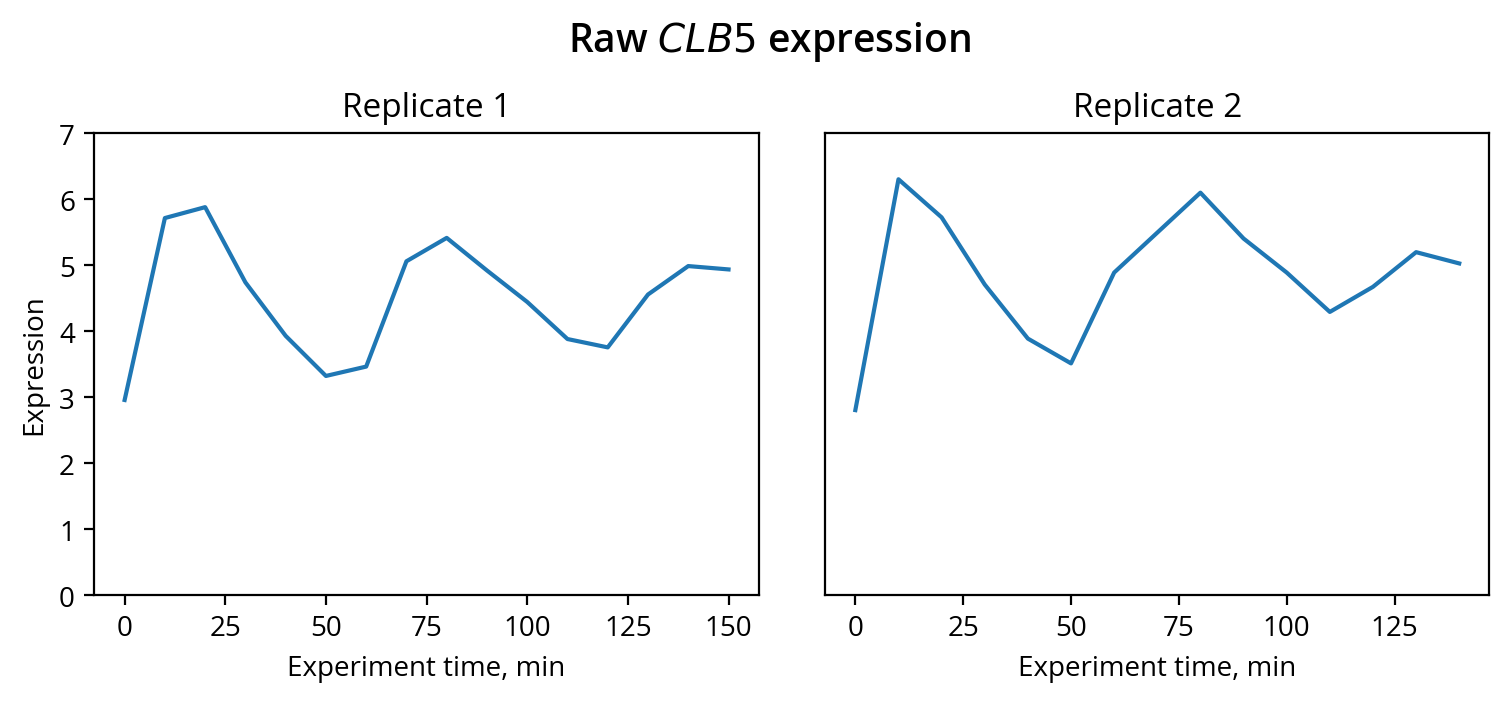

In [6]:
# Plot the raw expression for comparison

combined_g = expression_runner.expression_find_gamma.deconvolution_solver.g
expression_tps_rep1 = expression_runner.config1.timepoints
expression_tps_rep2 = expression_runner.config2.timepoints
rep1_g_raw = combined_g[:len(expression_tps_rep1)]
rep2_g_raw = combined_g[len(expression_tps_rep1):]

plt.figure(figsize=(9, 3))
plt.subplot(1, 2, 1)
plt.plot(expression_tps_rep1, rep1_g_raw)
plt.title("Replicate 1")
plt.ylim(0, 7)
plt.xlabel("Experiment time, min")
plt.ylabel("Expression")

plt.subplot(1, 2, 2)
plt.plot(expression_tps_rep2, rep2_g_raw)
plt.title("Replicate 2")
plt.ylim(0, 7)
plt.yticks([])
plt.subplots_adjust(wspace=0.1)
plt.xlabel("Experiment time, min")

plt.suptitle("Raw $\\it{CLB5}$ expression", fontweight='demi', fontsize=14, y=1.07)


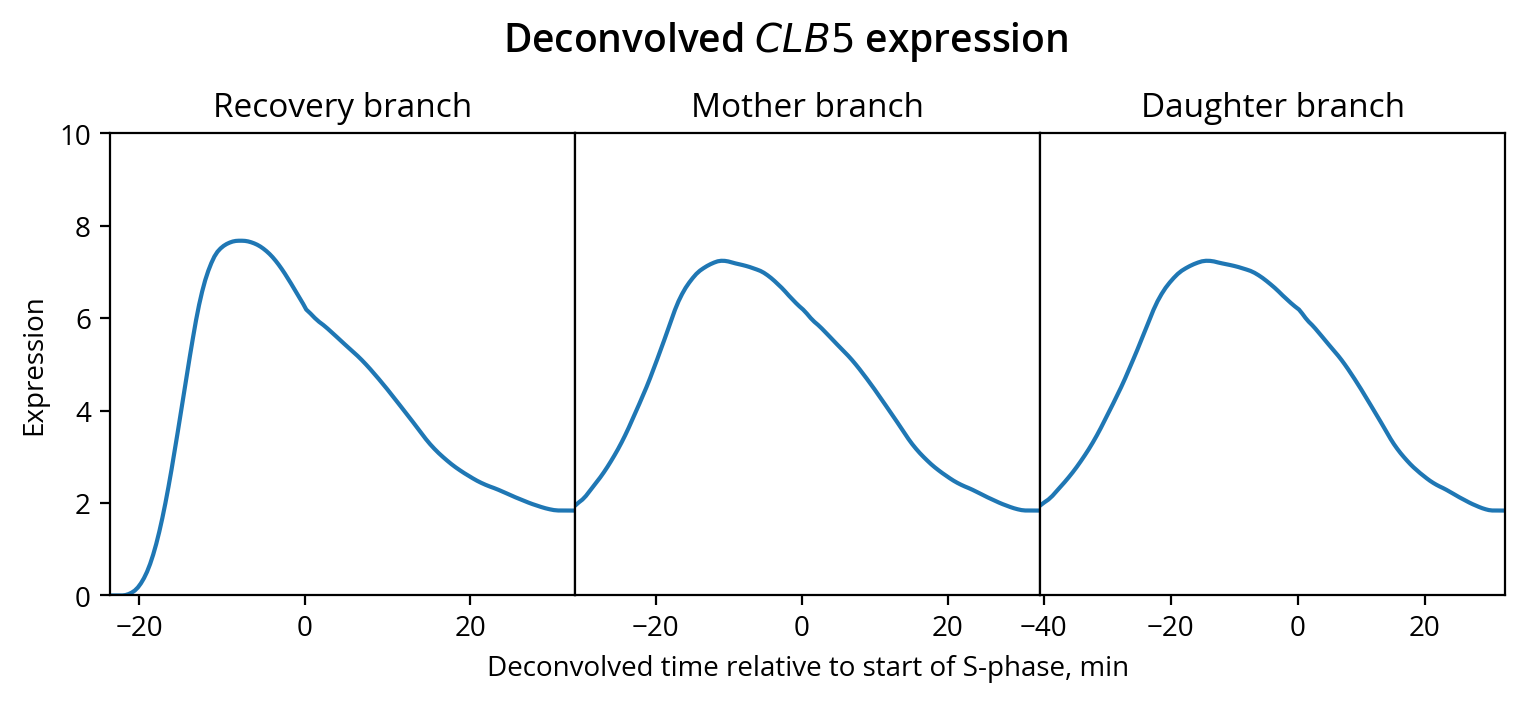

In [7]:
from src.config import get_average_timepoints_for_branch

# Retrieve the average timepoints (of replicates 1 and 2) for each branch
# for plotting
i_tps = get_average_timepoints_for_branch(config1, config2, 'i')
t_tps = get_average_timepoints_for_branch(config1, config2, 't')
b_tps = get_average_timepoints_for_branch(config1, config2, 'b')

# Plot the deconvolved branches for the expression
plt.figure(figsize=(9, 3))
plt.subplot(1, 3, 1)
plt.plot(i_tps, clb5_f[config1.i_indices()])
plt.ylim(0, 10)
plt.xlim(i_tps[0], i_tps[-1])
plt.ylabel("Expression")
plt.title("Recovery branch")

plt.subplot(1, 3, 2)
plt.plot(t_tps, clb5_f[config1.t_indices()])
plt.ylim(0, 10)
plt.xlim(t_tps[0], t_tps[-1])
plt.yticks([])
plt.xlabel("Deconvolved time relative to start of S-phase, min")
plt.title("Mother branch")

plt.subplot(1, 3, 3)
plt.plot(b_tps, clb5_f[config1.b_indices()])
plt.ylim(0, 10)
plt.xlim(b_tps[0], b_tps[-1])
plt.yticks([])
plt.title("Daughter branch")

plt.suptitle("Deconvolved $\\it{CLB5}$ expression", fontweight='demi', fontsize=14, y=1.07)
plt.subplots_adjust(wspace=0)


In [8]:
from src.expression_chromatin_plots import DeconvolutionChromatinExpressionPlotter
from src.ChromatinRNALocusPlotter import SingleBranchChromatinPlotter
from src.rna_pileup_plotter import RNASeqPileupPlotter
from pipeline.transcription_processor import ExpressionAnalysisProcessor
from src.deconvolved_tpm_plotter import DeconvolvedTPMPlotter

# For locus plotting
expression_processor = ExpressionAnalysisProcessor(example_output_dir)
expression_processor.setup_data_loaders()
expression_processor.load_deconvolved_expression()
tpm_plotter = DeconvolvedTPMPlotter(expression_processor.expression_data,
    expression_processor.all_transcripts_set)
rna_plotter = RNASeqPileupPlotter(example_output_dir)

Loaded 1 transcripts
  1 genic transcripts
  0 non-genic transcripts
Loading deconvolved gene expression data...
Loading deconvolved expression files, n= 1
Loaded expression data: 1 transcripts, 257 timepoints


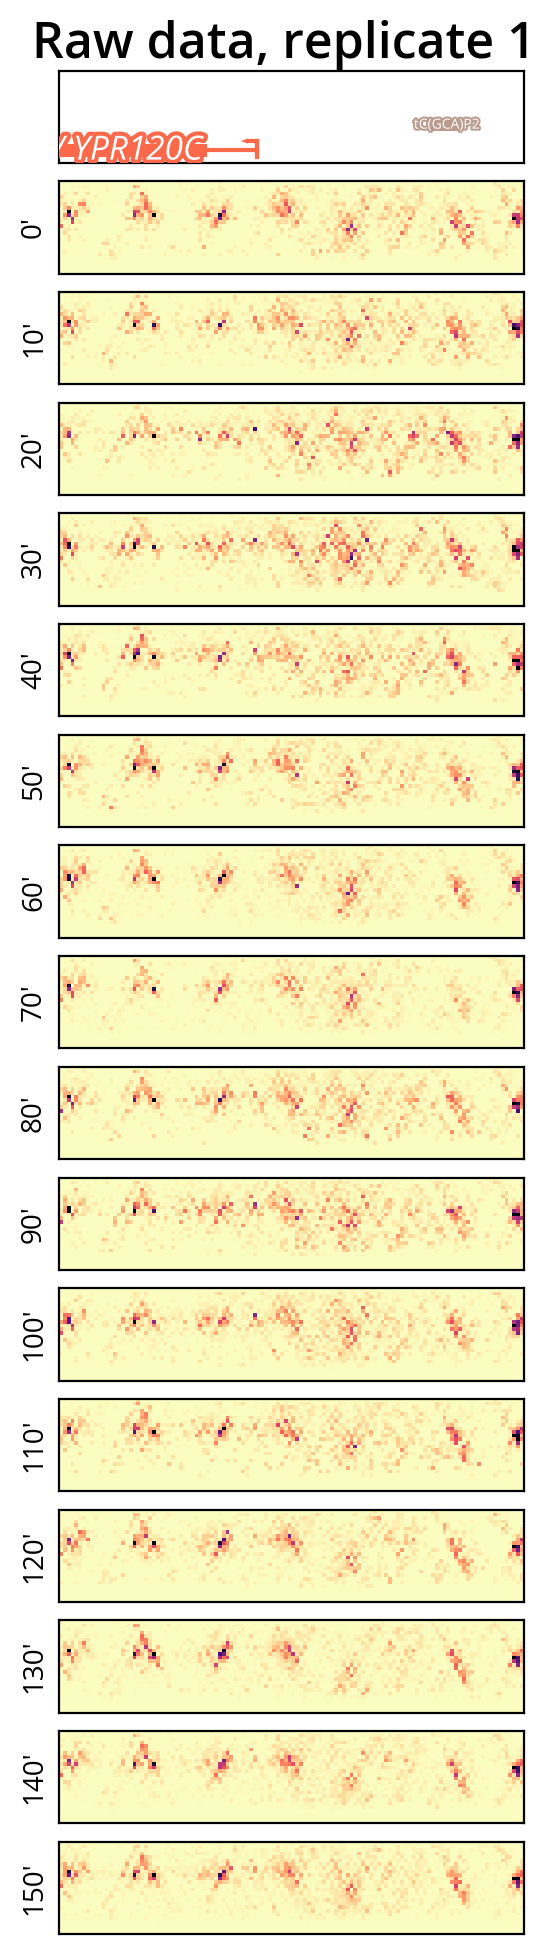

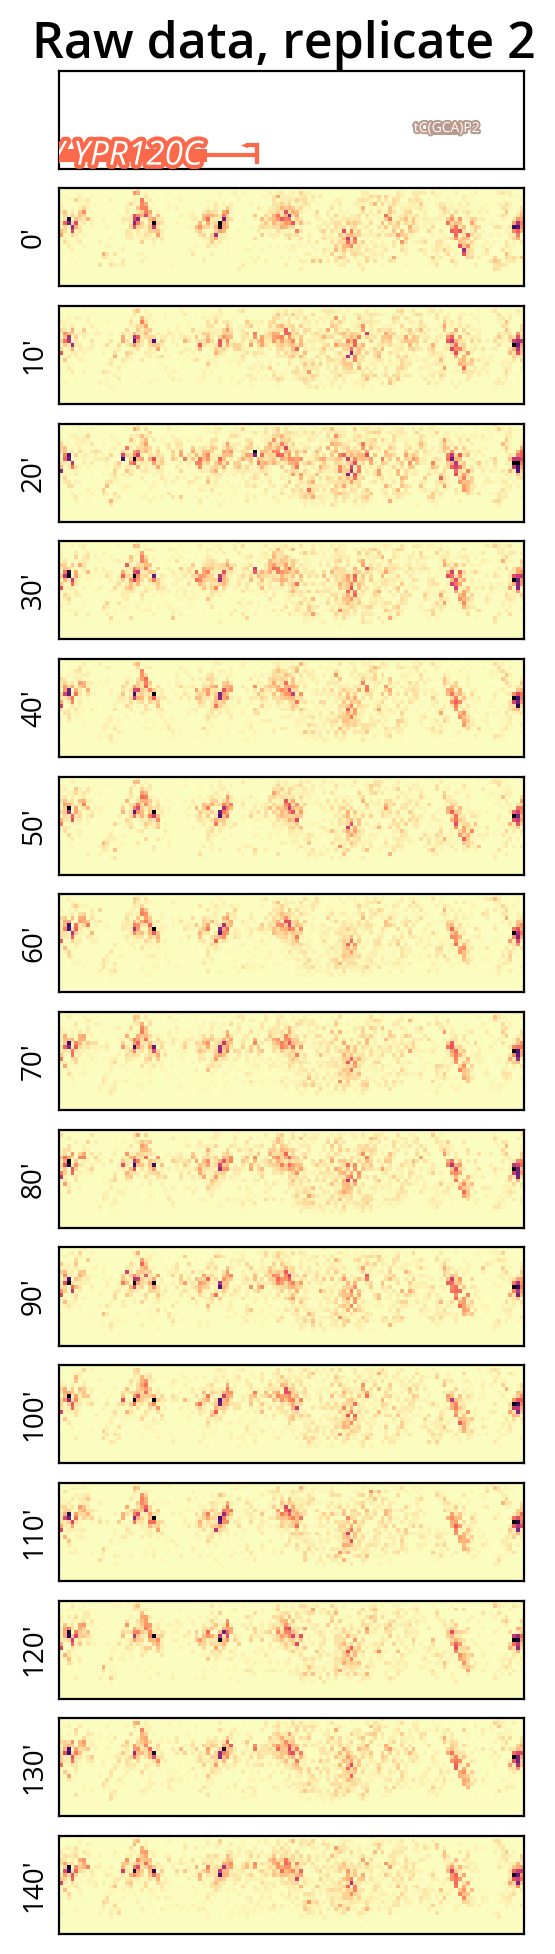

In [9]:
# Plot the raw chromatin data for each replicate for comparison
fig = combined_model.chrom1_model.plot_raw_data(figsize=(3, 11))
fig = combined_model.chrom2_model.plot_raw_data(figsize=(3, 11))

Creating directory: output/example/rna_seq_intermediate...Directory exists. Skipping.
Creating directory: output/example/rna_seq_intermediate/reads...Directory exists. Skipping.
Creating directory: output/example/rna_seq_intermediate/pileups...Directory exists. Skipping.
Initialized RNASeqIntermediateManager for chromosome 16
Intermediate directory: output/example/rna_seq_intermediate
Loaded pileups from watson_rna_seq_pileup_rep1_chr16.h5, crick_rna_seq_pileup_rep1_chr16.h5
Shape: (16, 1200) (timepoints x positions)
Loaded pileups from watson_rna_seq_pileup_rep2_chr16.h5, crick_rna_seq_pileup_rep2_chr16.h5
Shape: (14, 1200) (timepoints x positions)


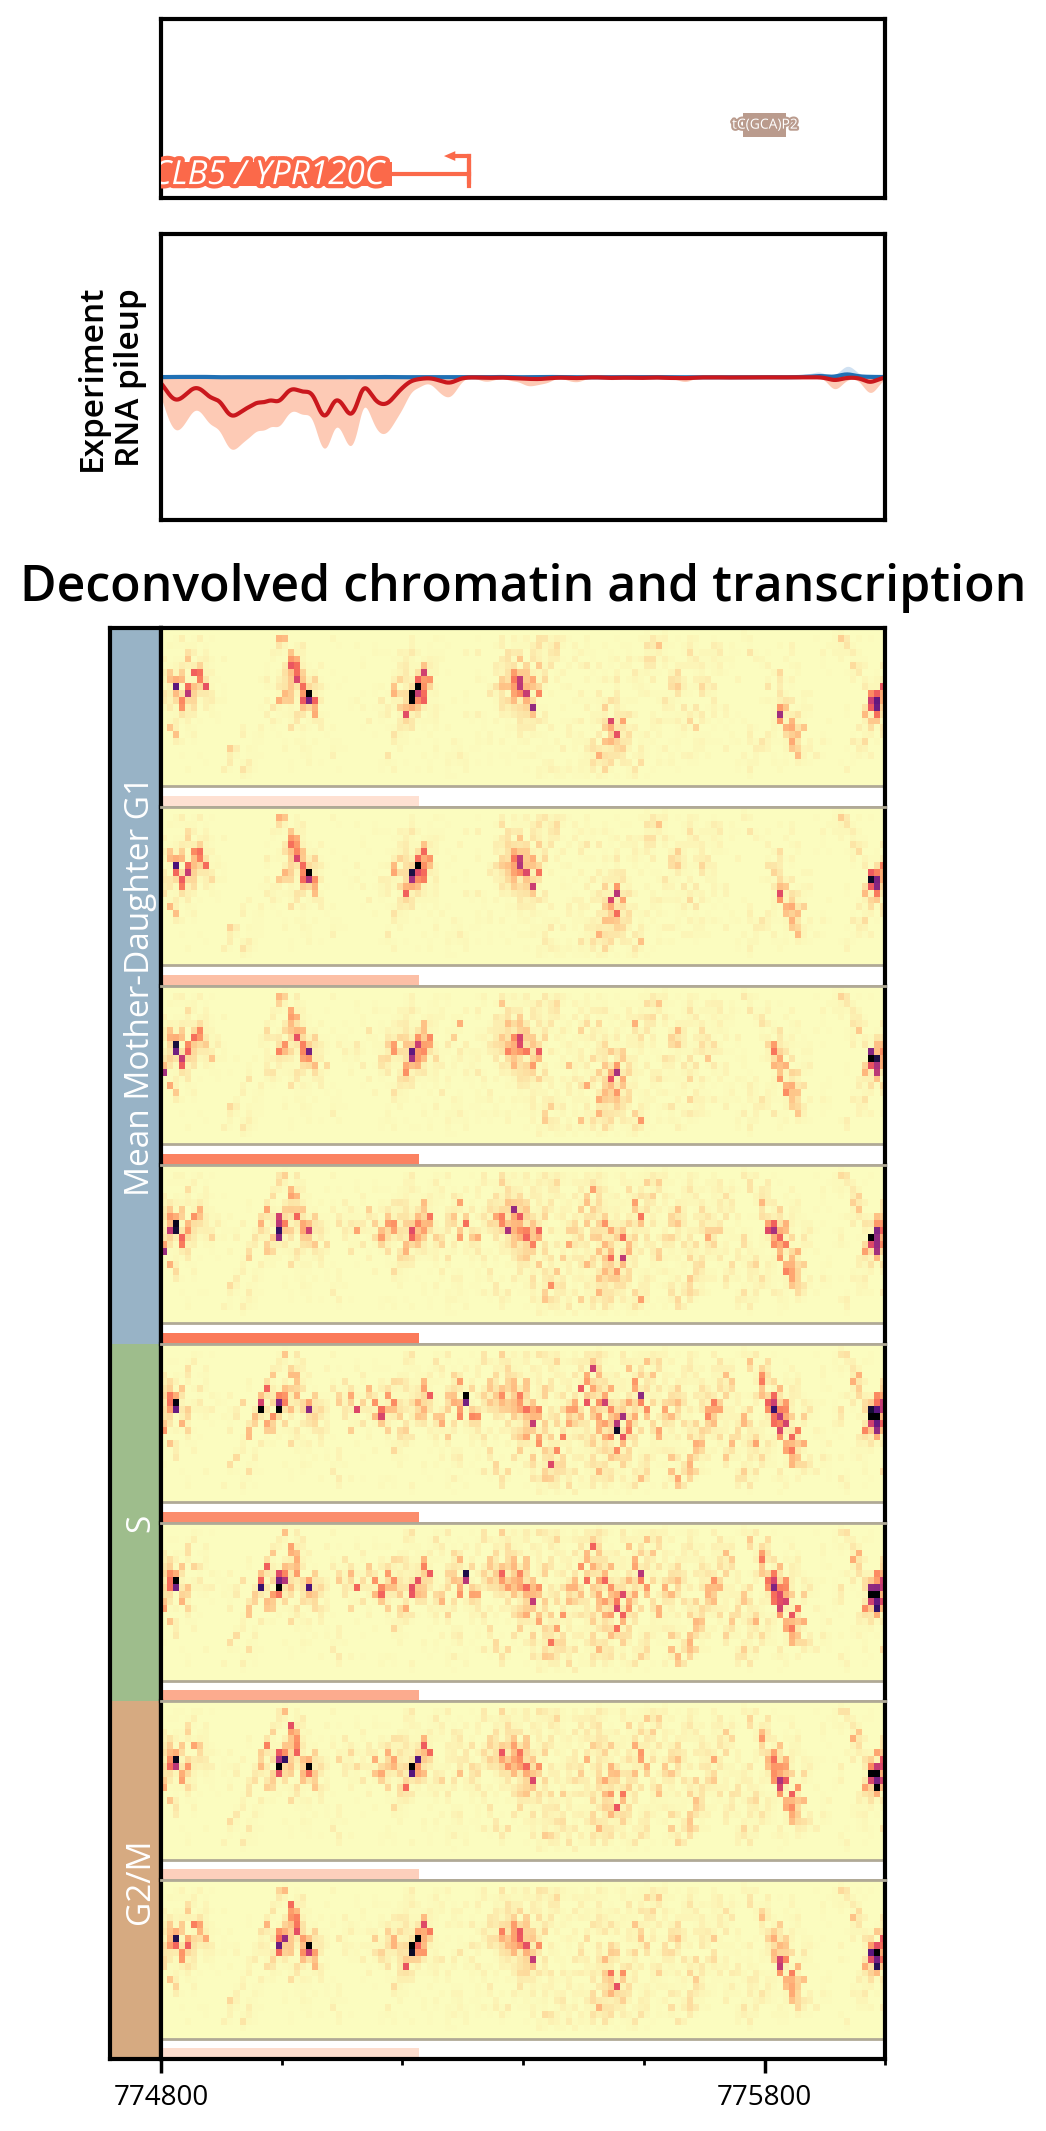

In [10]:
# Plot the deconvolved chromatin within the window
plotter = SingleBranchChromatinPlotter(
    outdir=None,
    config1=config1,
    figsize=(5, 12),
    branch_type='mean_mother_daughter',
    title='',
    rna_plotter=rna_plotter,
    deconvolved_tpm_plotter=tpm_plotter,
    plot_index_labels=False
)

img_shape = combined_model.chrom1_model.image_shape
plotter.set_chrom_span(chrom, mnase_span)
plotter.set_chromatin_data(combined_model.F.reshape(-1, img_shape[0], img_shape[1]))

fig = plotter.plot()